<a href="https://colab.research.google.com/github/soseverse/Application-of-remote-sensing-and-deep-learning---Sand-mining-detection-at-Vietnam-Mekong-Delta/blob/colab-progress/sm_project_oversampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### imported libraries

In [102]:
pip install --upgrade --force-reinstall pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.7/411.7 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 131.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pycocotools
    Found existing installation: pycocotools 2.0.11
    Uninstalling pycocotools-2.0.11:
      Successfully uninstalled pycocotools-2.0.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.


In [1]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 82.6 MB/s eta 0:00:00


In [2]:
pip install tensorflow

In [119]:
import numpy as np
import pandas as pd
import os
import shutil
import yaml
import json
import matplotlib.pyplot as plt
import random

import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image
from IPython.display import display

from ultralytics import YOLO

import torch
import numpy as np
from tqdm import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval


### load dataset

In [4]:
dataset_path = '/content/drive/MyDrive/sm_vmd_data'

def show_contents(path):
  for name in os.listdir(path):
    full_path = os.path.join(path, name)
    if os.path.isdir(full_path):
      print(f'{name}/ - {len(os.listdir(full_path))} files')

In [5]:
show_contents(dataset_path)

train_labels/ - 3502 files
train_images/ - 3502 files


### dataset cleaning

In [6]:
def remove_empty_labels(old_dir, new_dir):
  os.makedirs(new_dir, exist_ok = True)
  count = 0 # to count number of files with empty label
  for name in os.listdir(old_dir):
    full_path = os.path.join(old_dir, name)
    if os.path.isfile(full_path) and os.path.getsize(full_path) > 0:
      shutil.copy(full_path, new_dir)
    else:
      count = count + 1

  print(f'Total empty label files: {count}')

In [7]:
label_dir = os.path.join(dataset_path, 'train_labels')
cleaned_data_dir = os.path.join(dataset_path, 'cleaned_dataset')

remove_empty_labels(label_dir, cleaned_data_dir)

Total empty label files: 326


### analysis of annotated objects

In [8]:
# check data.yaml file
with open("/content/drive/MyDrive/sm_vmd_data/data.yaml", "r") as f:
    data_yaml = yaml.safe_load(f)


In [9]:
nc = data_yaml['nc']
names = data_yaml['names']


### Get class IDs

In [10]:
all_class_counts = {}

for filename in os.listdir(cleaned_data_dir):
    if not filename.endswith(".txt"):
        continue

    with open(os.path.join(cleaned_data_dir, filename)) as file:
        for line in file:
            class_id = int(line.split()[0])

            if class_id not in all_class_counts:
                all_class_counts[class_id] = 1
            else:
               all_class_counts[class_id] += 1


In [11]:
all_class_counts

{2: 16727, 1: 5996, 0: 2848, 3: 255}

### valid classes

In [12]:
for class_id in range(nc):
    class_name = names[class_id]
    count = all_class_counts[class_id]
    print(f"Class {class_id} ({class_name}): {count}")

Class 0 (barge with crane): 2848
Class 1 (cluster of boats): 5996
Class 2 (sand transport boat): 16727


### Handling invalid class

In [13]:
invalid_classes = []

for class_id, count in all_class_counts.items():
    if class_id >= nc:
        invalid_classes.append((class_id, count))

if len(invalid_classes) > 0:
    print("\nInvalid classes found:")
    for item in invalid_classes:
        cid = item[0]
        count = item[1]
        print(f"Class ID {cid}: {count} annotations")
else:
    print("\nNo invalid classes found.")



Invalid classes found:
Class ID 3: 255 annotations


### Dataset Visualisation

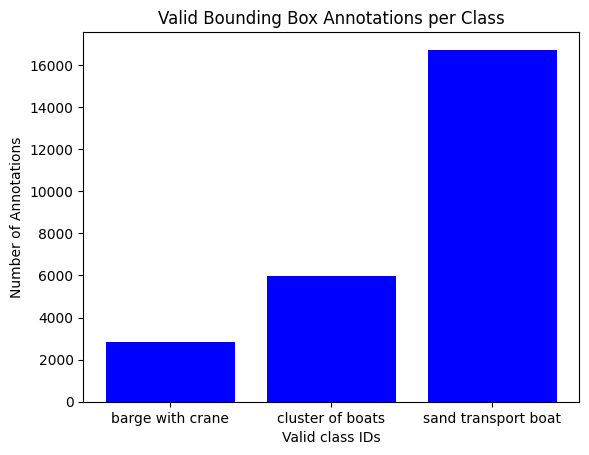

In [14]:
class_ids = list(range(nc))
counts = [all_class_counts[class_id] for class_id in class_ids]
labels = [names[class_id] for class_id in class_ids]

plt.figure()
plt.bar(labels, counts, color = 'blue')
plt.xlabel("Valid class IDs")
plt.ylabel("Number of Annotations")
plt.title("Valid Bounding Box Annotations per Class")
plt.show()


### Dataset analysis wrt images

In [15]:
class_images = {}

for filename in os.listdir(cleaned_data_dir):
    if not filename.endswith(".txt"):
        continue

    with open(os.path.join(cleaned_data_dir, filename)) as file:
        for line in file:
            class_id = int(line.split()[0])

            if class_id not in class_images:
                class_images[class_id] = []

            if filename not in class_images[class_id]:
                class_images[class_id].append(filename)


In [16]:
print("Total images per valid class:")

for class_id in range(nc):
    class_name = names[class_id]
    image_count = len(class_images[class_id])
    print(f"Class {class_id} ({class_name}): {image_count} images")


Total images per valid class:
Class 0 (barge with crane): 1494 images
Class 1 (cluster of boats): 1878 images
Class 2 (sand transport boat): 2619 images


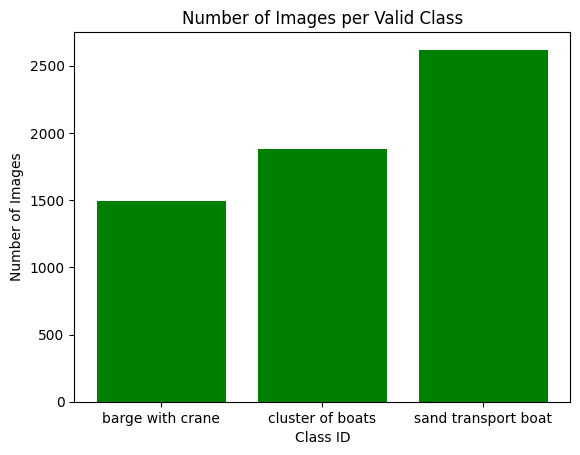

In [17]:
valid_class_ids = []
image_counts = []

for class_id in range(nc):
    valid_class_ids.append(names[class_id])

    if class_id in class_images:
        image_counts.append(len(class_images[class_id]))
    else:
        image_counts.append(0)

plt.figure()
plt.bar(valid_class_ids, image_counts, color = 'green')
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.title("Number of Images per Valid Class")
plt.show()


### Validation dataset

In [18]:
image_classes = {}

for filename in os.listdir(cleaned_data_dir):
  if not filename.endswith('txt'):
    continue
  with open(os.path.join(cleaned_data_dir, filename)) as file:
    for line in file:
      class_id = int(line.split()[0])
      if filename not in image_classes:
        image_classes[filename] = []

      if class_id not in image_classes[filename]:
        image_classes[filename].append(class_id)

In [19]:
class_image_counts = {}

for classes in image_classes.values():
  for class_id in classes:
    if class_id not in class_image_counts:
      class_image_counts[class_id] = 1
    else:
      class_image_counts[class_id] += 1

In [20]:
val_size = 0.20
target_val_counts = {}
for class_id in range(nc):
  if class_id in class_image_counts:
    target_val_counts[class_id] = int(class_image_counts[class_id] * val_size)
  else:
    target_val_counts[class_id] = 0

In [21]:
target_val_counts

{0: 298, 1: 375, 2: 523}

### Extract validation images from dataset

In [22]:
val_counts = {}

for class_id in target_val_counts:
  val_counts[class_id] = target_val_counts[class_id]

# store validation images in new list
val_images = []
image_names = list(image_classes.keys())
random.shuffle(image_names)

for image_name in image_names:
  classes = image_classes[image_name]
  for class_id in classes:
    if class_id in val_counts:
      if val_counts[class_id] > 0:
        val_images.append(image_name)

        # receeding count of val_counts
        for class_ in classes:
          if class_ in val_counts:
            if val_counts[class_] > 0:
              val_counts[class_] -= 1
        break


In [23]:
train_images = []

for image_name in image_classes:
  if image_name not in val_images:
    train_images.append(image_name)

print(f'Total validation images: ({len(val_images)})')
print(f'Total training images: ({len(train_images)})')

Total validation images: (636)
Total training images: (2540)


In [24]:
new_dataset_path = 'vmd'

train_images_dir = os.path.join(new_dataset_path, 'images/train')
train_labels_dir = os.path.join(new_dataset_path, 'labels/train')

val_images_dir = os.path.join(new_dataset_path, 'images/val')
val_labels_dir = os.path.join(new_dataset_path, 'labels/val')

os.makedirs(train_images_dir, exist_ok = True)
os.makedirs(train_labels_dir, exist_ok = True)
os.makedirs(val_images_dir, exist_ok = True)
os.makedirs(val_labels_dir, exist_ok = True)



### for train images

In [25]:
for label_name in train_images:

    image_name = label_name.replace(".txt", ".jpg")

    shutil.copy(
        os.path.join("/content/drive/MyDrive/sm_vmd_data/train_images", image_name),
        os.path.join(train_images_dir, image_name)
    )


    shutil.copy(
        os.path.join(cleaned_data_dir, label_name),
        os.path.join(train_labels_dir, label_name)
    )


### for validation images

In [26]:
for label_name in val_images:

    image_name = label_name.replace(".txt", ".jpg")

    shutil.copy(
        os.path.join("/content/drive/MyDrive/sm_vmd_data/train_images", image_name),
        os.path.join(val_images_dir, image_name)
    )

    shutil.copy(
        os.path.join(cleaned_data_dir, label_name),
        os.path.join(val_labels_dir, label_name)
    )


In [27]:
print("Train images:", len(os.listdir(train_images_dir)))
print("Train labels:", len(os.listdir(train_labels_dir)))
print("Val images:", len(os.listdir(val_images_dir)))
print("Val labels:", len(os.listdir(val_labels_dir)))


Train images: 2540
Train labels: 2540
Val images: 636
Val labels: 636


## VGG 16 - Baseline Model

### create VGG-16 dataset for classification

In [28]:
images_dir = "/content/vmd/images/train"
labels_dir = "/content/vmd/labels/train"
vgg_16_path = "/content/vgg_16"

os.makedirs(vgg_16_path, exist_ok=True)

for label_file in os.listdir(labels_dir):

    if not label_file.endswith(".txt"):
        continue

    image_file = label_file.replace(".txt", ".jpg")

    image_path = os.path.join(images_dir, image_file)
    label_path = os.path.join(labels_dir, label_file)

    if not os.path.exists(image_path):
        continue

    img = Image.open(image_path)
    w, h = img.size

    with open(label_path) as f:
        for i, line in enumerate(f):

            parts = line.split()
            class_id = int(parts[0])

            if class_id >= 3:
                continue
            # Yolo coordinates
            xc = float(parts[1])
            yc = float(parts[2])
            bw = float(parts[3])
            bh = float(parts[4])

            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)

            # Bounding box axis boundary
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(w, x2)
            y2 = min(h, y2)

            # invalid crops
            if x2 <= x1 or y2 <= y1:
                continue

            crop = img.crop((x1, y1, x2, y2))

            class_folder = os.path.join(vgg_16_path, str(class_id))
            os.makedirs(class_folder, exist_ok=True)

            save_name = f"{label_file[:-4]}_{i}.jpg"
            save_path = os.path.join(class_folder, save_name)

            crop.save(save_path)

print("VGG16 crops created successfully.")


VGG16 crops created successfully.


In [29]:
print(os.listdir(vgg_16_path))

['1', '0', '2']


### Splitting crops into train and validation set

In [30]:
source_dir = "/content/vgg_16"
base_dir = "/content/vgg16_data"

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

random.seed(42)

for class_id in os.listdir(source_dir):

    class_source = os.path.join(source_dir, class_id)
    if not os.path.isdir(class_source):
        continue

    class_train = os.path.join(train_dir, class_id)
    class_val   = os.path.join(val_dir, class_id)

    os.makedirs(class_train, exist_ok=True)
    os.makedirs(class_val, exist_ok=True)

    images = os.listdir(class_source)
    random.shuffle(images)

    split_idx = int(len(images) * 0.8)

    train_imgs = images[:split_idx]
    val_imgs   = images[split_idx:]

    for img in train_imgs:
        shutil.copy(os.path.join(class_source, img),
                    os.path.join(class_train, img))

    for img in val_imgs:
        shutil.copy(os.path.join(class_source, img),
                    os.path.join(class_val, img))


### Data Preprocessing

In [31]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)


In [32]:
train_generator = train_datagen.flow_from_directory(
    "/content/vgg16_data/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    "/content/vgg16_data/val",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)


Found 16562 images belonging to 3 classes.
Found 4141 images belonging to 3 classes.


### Building VGG-16 Model

In [33]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [34]:
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation="relu")(x)
output = Dense(3, activation="softmax")(x)




In [35]:
model = Model(inputs=base_model.input, outputs=output)

In [36]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [37]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2
)


Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


518/518 ━━━━━━━━━━━━━━━━━━━━ 34s 52ms/step - accuracy: 0.7332 - loss: 0.8633 - val_accuracy: 0.7679 - val_loss: 0.5777
Epoch 2/2
518/518 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.7977 - loss: 0.5279 - val_accuracy: 0.7935 - val_loss: 0.5171


### Check accuracy and loss for baseline model

In [38]:
val_loss, val_acc = model.evaluate(val_generator)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)


130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7953 - loss: 0.5053
Validation Loss: 0.5170773863792419
Validation Accuracy: 0.793528139591217


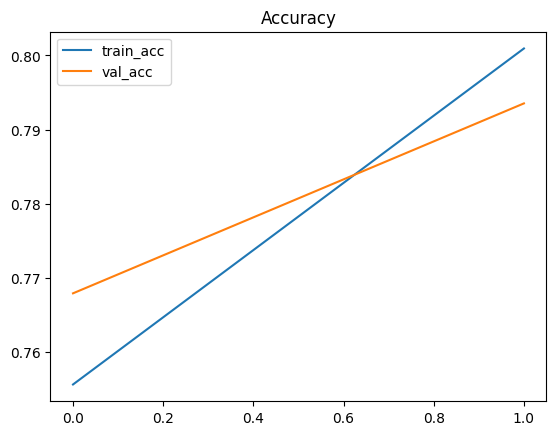

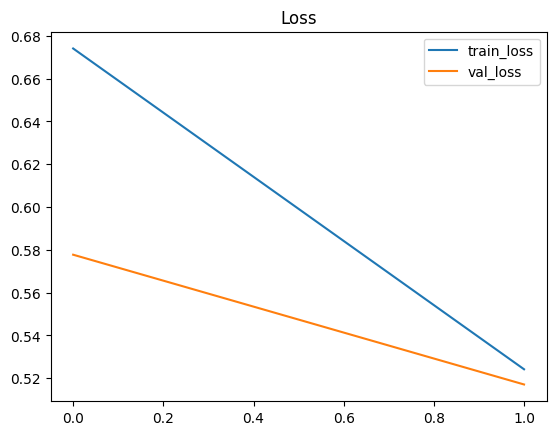

In [39]:
# Accuracy plot
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()


### VGG-16 Model tuning

In [40]:
# Adding 4 more layers
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False


In [41]:
model_ft1 = Model(inputs=base_model.input, outputs=output)

In [42]:
model_ft1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [43]:
history_ft1 = model_ft1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2
)


Epoch 1/2
518/518 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8348 - loss: 0.4423 - val_accuracy: 0.8242 - val_loss: 0.4572
Epoch 2/2
518/518 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.8554 - loss: 0.3876 - val_accuracy: 0.8324 - val_loss: 0.4391


In [44]:
val_loss, val_acc = model_ft1.evaluate(val_generator)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)


130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8367 - loss: 0.4340
Validation Loss: 0.4391433298587799
Validation Accuracy: 0.8324076533317566


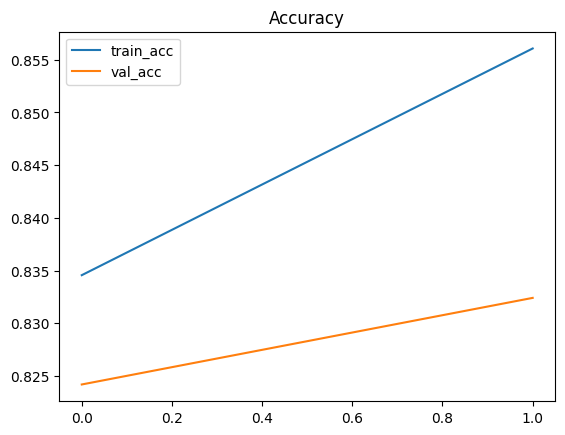

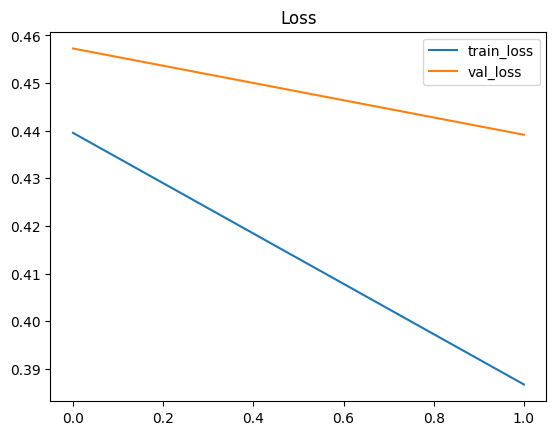

In [45]:
# Accuracy plot
plt.plot(history_ft1.history["accuracy"], label="train_acc")
plt.plot(history_ft1.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history_ft1.history["loss"], label="train_loss")
plt.plot(history_ft1.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()


In [46]:
# Adding another 8 layers
for layer in base_model.layers[:-8]:
    layer.trainable = False



In [47]:
model_ft2 = Model(inputs=base_model.input, outputs=output)

In [48]:
model_ft2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [49]:
history_ft2 = model_ft2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2
)


Epoch 1/2
518/518 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.8734 - loss: 0.3421 - val_accuracy: 0.8401 - val_loss: 0.4158
Epoch 2/2
518/518 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.8856 - loss: 0.3177 - val_accuracy: 0.8387 - val_loss: 0.4124


In [50]:
val_loss_vgg, val_acc_vgg = model_ft2.evaluate(val_generator)

print("Validation Loss:", val_loss_vgg)
print("Validation Accuracy:", val_acc_vgg)


130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8383 - loss: 0.4070
Validation Loss: 0.4124147593975067
Validation Accuracy: 0.8386862874031067


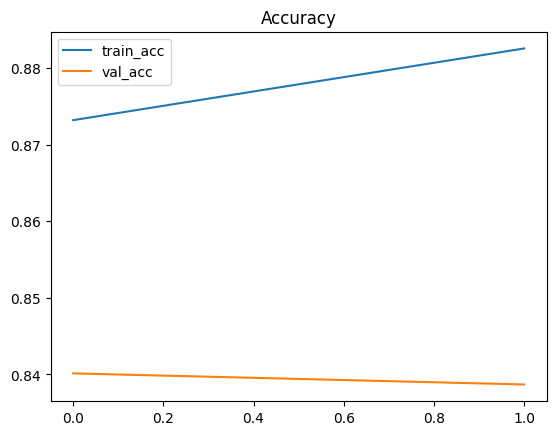

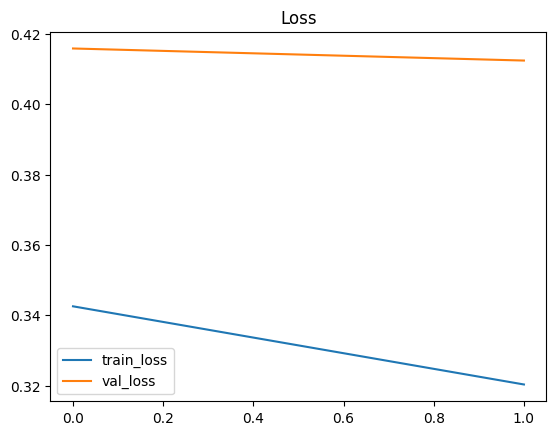

In [51]:
# Accuracy plot
plt.plot(history_ft2.history["accuracy"], label="train_acc")
plt.plot(history_ft2.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history_ft2.history["loss"], label="train_loss")
plt.plot(history_ft2.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()


### Test Model

In [52]:
true_labels = val_generator.classes
val_generator.reset()
predictions = model_ft1.predict(val_generator)
pred_labels = np.argmax(predictions, axis=1)

130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step


### Confusion Matrix

In [53]:
cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:")
print(cm)



Confusion Matrix:
[[  30   80  347]
 [  81  185  695]
 [ 243  501 1979]]


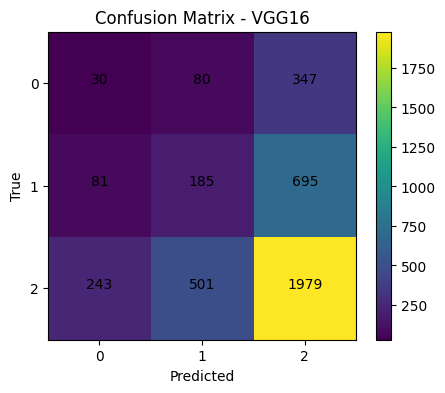

In [54]:
# Visualise confusion matrix
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest', cmap='viridis')
plt.title("Confusion Matrix - VGG16")
plt.colorbar()

class_names = list(val_generator.class_indices.keys())
plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted")
plt.ylabel("True")

# Add values to the plot
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 horizontalalignment="center")

plt.show()



### Classification Report

In [55]:
print(classification_report(true_labels, pred_labels, target_names=class_names))

              precision    recall  f1-score   support

           0       0.08      0.07      0.07       457
           1       0.24      0.19      0.21       961
           2       0.66      0.73      0.69      2723

    accuracy                           0.53      4141
   macro avg       0.33      0.33      0.33      4141
weighted avg       0.50      0.53      0.51      4141



### Building the ResNet-50 Model

In [56]:
# Let's work with a Pre-trained Imagenet model
resnet_base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
resnet_base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [57]:
x = resnet_base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)

output = Dense(3, activation="softmax")(x)




In [58]:
resnet_model = Model(inputs=resnet_base_model.input, outputs=output)

In [59]:
resnet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [60]:
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2
    )

Epoch 1/2
518/518 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.6520 - loss: 0.8826 - val_accuracy: 0.6663 - val_loss: 0.8441
Epoch 2/2
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.6746 - loss: 0.8140 - val_accuracy: 0.6865 - val_loss: 0.8082


In [61]:
val_loss_resnet, val_acc_resnet = resnet_model.evaluate(val_generator)

print("ResNet50 Final Validation Accuracy:", val_acc_resnet)
print("ResNet50 Final Validation Loss:", val_loss_resnet)

130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6828 - loss: 0.8141
ResNet50 Final Validation Accuracy: 0.6865491271018982
ResNet50 Final Validation Loss: 0.8082056045532227


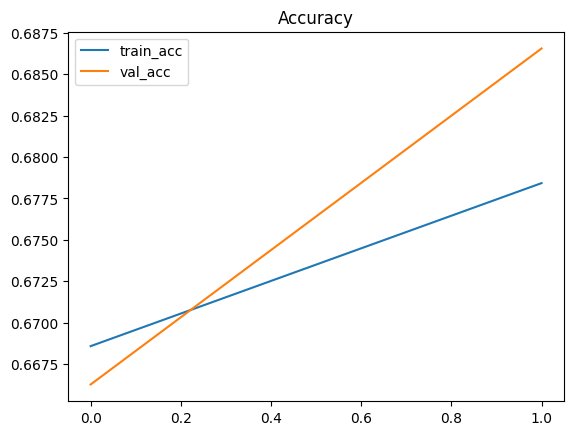

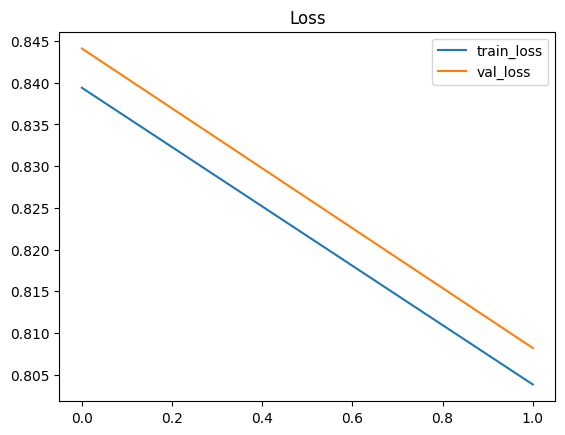

In [62]:
# Accuracy plot
plt.plot(history_resnet.history["accuracy"], label="train_acc")
plt.plot(history_resnet.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history_resnet.history["loss"], label="train_loss")
plt.plot(history_resnet.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()


In [63]:
# checking number of layers
len(resnet_base_model.layers)

175

### Finetuning ResNet50

In [64]:
resnet_base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False


In [65]:
resnet_model_ft1 = Model(inputs=resnet_base_model.input, outputs=output)

In [66]:
resnet_model_ft1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [67]:
history_resnet_ft1 = resnet_model_ft1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2
)


Epoch 1/2
518/518 ━━━━━━━━━━━━━━━━━━━━ 111s 113ms/step - accuracy: 0.6593 - loss: 0.9602 - val_accuracy: 0.6245 - val_loss: 1.0986
Epoch 2/2
518/518 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.8328 - loss: 0.4436 - val_accuracy: 0.7474 - val_loss: 0.6360


In [68]:
val_loss_resnet, val_acc_resnet = resnet_model_ft1.evaluate(val_generator)

print("ResNet50 Final Validation Accuracy:", val_acc_resnet)
print("ResNet50 Final Validation Loss:", val_loss_resnet)


130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.7499 - loss: 0.6167
ResNet50 Final Validation Accuracy: 0.7474039793014526
ResNet50 Final Validation Loss: 0.6360463500022888


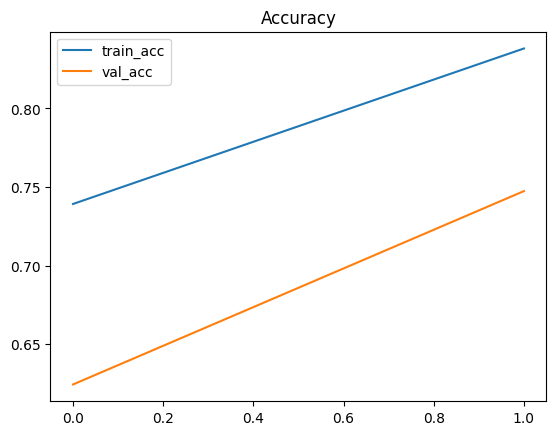

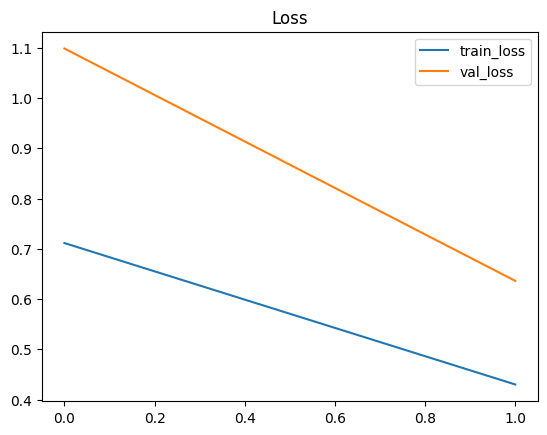

In [69]:
# Accuracy plot
plt.plot(history_resnet_ft1.history["accuracy"], label="train_acc")
plt.plot(history_resnet_ft1.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history_resnet_ft1.history["loss"], label="train_loss")
plt.plot(history_resnet_ft1.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()


In [70]:
resnet_base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False


In [71]:
resnet_model_ft2 = Model(inputs=resnet_base_model.input, outputs=output)

In [72]:
resnet_model_ft2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [73]:
history_resnet_ft2 = resnet_model_ft2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2
)


Epoch 1/2
518/518 ━━━━━━━━━━━━━━━━━━━━ 105s 108ms/step - accuracy: 0.8391 - loss: 0.4233 - val_accuracy: 0.8375 - val_loss: 0.4262
Epoch 2/2
518/518 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.8991 - loss: 0.2719 - val_accuracy: 0.8657 - val_loss: 0.3779


In [74]:
val_loss_resnet, val_acc_resnet = resnet_model_ft2.evaluate(val_generator)

print("ResNet50 Final Validation Accuracy:", val_acc_resnet)
print("ResNet50 Final Validation Loss:", val_loss_resnet)


130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8635 - loss: 0.3635
ResNet50 Final Validation Accuracy: 0.8657329082489014
ResNet50 Final Validation Loss: 0.3778828978538513


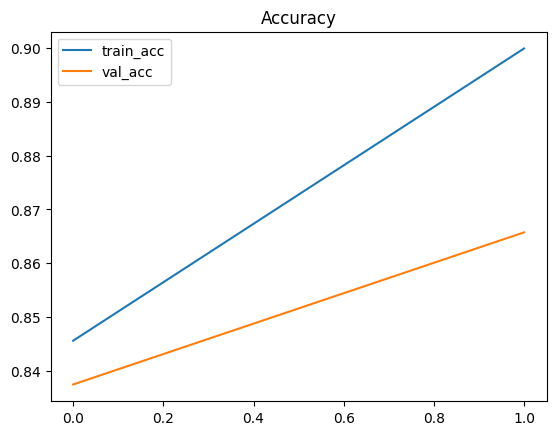

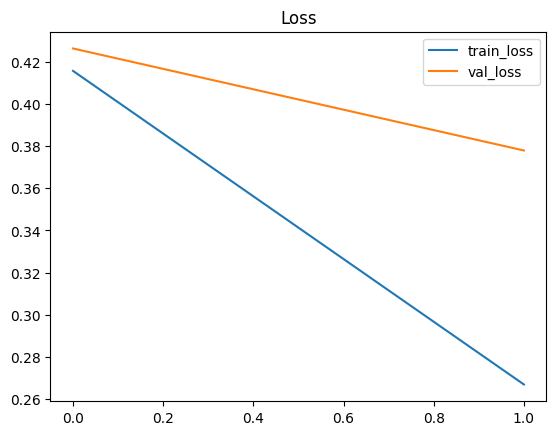

In [75]:
# Accuracy plot
plt.plot(history_resnet_ft2.history["accuracy"], label="train_acc")
plt.plot(history_resnet_ft2.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history_resnet_ft2.history["loss"], label="train_loss")
plt.plot(history_resnet_ft2.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()


### Confusion matrix for ResNet-50

In [76]:
val_generator.reset()
resnet_predictions = resnet_model_ft2.predict(val_generator)
resnet_pred_labels = np.argmax(resnet_predictions, axis=1)

130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step


Confusion Matrix - ResNet50:
[[  41  105  311]
 [ 105  234  622]
 [ 297  666 1760]]


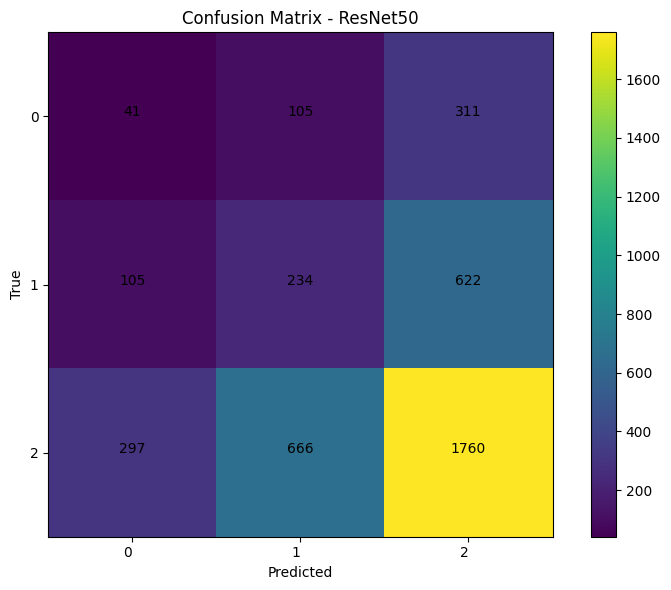

In [77]:
cm_resnet = confusion_matrix(true_labels, resnet_pred_labels)
print("Confusion Matrix - ResNet50:")
print(cm_resnet)

plt.figure(figsize=(8, 6))
plt.imshow(cm_resnet, interpolation='nearest', cmap='viridis')
plt.title("Confusion Matrix - ResNet50")
plt.colorbar()

class_names = list(val_generator.class_indices.keys())
plt.xticks(range(len(class_names)), class_names, ha='right')
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted")
plt.ylabel("True")

# Add values to the plot
for i in range(cm_resnet.shape[0]):
    for j in range(cm_resnet.shape[1]):
        plt.text(j, i, str(cm_resnet[i, j]),
                 horizontalalignment="center")

plt.tight_layout()
plt.show()

In [78]:
print("\nResNet50 Classification Report:")
print(classification_report(true_labels, resnet_pred_labels, target_names=class_names))


ResNet50 Classification Report:
              precision    recall  f1-score   support

           0       0.09      0.09      0.09       457
           1       0.23      0.24      0.24       961
           2       0.65      0.65      0.65      2723

    accuracy                           0.49      4141
   macro avg       0.33      0.33      0.33      4141
weighted avg       0.49      0.49      0.49      4141



### Classification Model Comparison

In [79]:
print(f"VGG16:  Acc: {val_acc_vgg:.4f}, Loss: {val_loss_vgg:.4f}")
print(f"ResNet50: Acc: {val_acc_resnet:.4f}, Loss: {val_loss_resnet:.4f}")

VGG16:  Acc: 0.8387, Loss: 0.4124
ResNet50: Acc: 0.8657, Loss: 0.3779


## Building Yolo-v8 Model

In [80]:
model = YOLO("yolov8m.pt")

In [81]:
print(os.listdir("/content/vmd/images/train")[:5])
print(os.listdir("/content/vmd/images/val")[:5])

['165_png.rf.384a1de77c5cd69527f6c2aad5fa56c8.jpg', '064_png.rf.8d05040db6730cc3859009a5c1ee9e00.jpg', '030-2-_png.rf.6d5a5a91fc2d19f2411771dc2a8b39c2.jpg', 'Screenshot-276-_png.rf.df0bee1ef42609ab51733230135331cb.jpg', '152-2-_png.rf.2eaebcedc93d6b6441ace208223f6759.jpg']
['0105_jpg.rf.4b1d4e1f9c4daa3c9cb13621fabb9724.jpg', '246_png.rf.bac660c06ed4eff4e4ccb12ce6acc03c.jpg', '243_png.rf.29ccb3ccbdf99216d7e721c11cc9de40.jpg', '0116_jpg.rf.1c1e109eab544a8558d2c8058f8fd91c.jpg', '129-2-_png.rf.73f0f750942f09f95ab580d3ac7bd785.jpg']


### First Yolo training

In [82]:
results = model.train(
    data="/content/drive/MyDrive/sm_vmd_data/data.yaml",
    epochs=2,
    imgsz=768,
    batch=32,
    patience = 20,
    device = 0
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/sm_vmd_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

In [83]:
model = YOLO("runs/detect/train/weights/best.pt")

In [84]:
metrics = model.val()
metrics

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1024.4±381.9 MB/s, size: 29.9 KB)
val: Scanning /content/vmd/labels/val.cache... 636 images, 0 backgrounds, 13 corrupt: 100% ━━━━━━━━━━━━ 636/636 242.5Mit/s 0.0s
val: /content/vmd/images/val/0026_jpg.rf.37dd6ab0757add74e13c0ee7b93652e3.jpg: 1 duplicate labels removed
val: /content/vmd/images/val/0026_jpg.rf.96087a8c23194fe92e6781cf53109eb2.jpg: 1 duplicate labels removed
val: /content/vmd/images/val/Screenshot-248-_png.rf.aab16a57cf5b02f0ab69f28a88c45f7d.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 3. Possible class labels are 0-2
val: /content/vmd/images/val/Screenshot-261-_png.rf.85b4863800c64af2485edd9b2eba0a91.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 3. Possible class labels are 0-2
val: /co

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d4d7ed34770>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

### Second Yolo training

In [85]:
model = YOLO("yolov8l.pt")

results = model.train(
    data="/content/drive/MyDrive/sm_vmd_data/data.yaml",
    epochs=2,
    imgsz=1024,
    batch=32,
    patience=50,
    device=0
)


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/sm_vmd_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

In [86]:
model = YOLO("runs/detect/train/weights/best.pt")

In [87]:
metrics = model.val()
metrics

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1274.4±463.8 MB/s, size: 37.4 KB)
val: Scanning /content/vmd/labels/val.cache... 636 images, 0 backgrounds, 13 corrupt: 100% ━━━━━━━━━━━━ 636/636 222.3Mit/s 0.0s
val: /content/vmd/images/val/0026_jpg.rf.37dd6ab0757add74e13c0ee7b93652e3.jpg: 1 duplicate labels removed
val: /content/vmd/images/val/0026_jpg.rf.96087a8c23194fe92e6781cf53109eb2.jpg: 1 duplicate labels removed
val: /content/vmd/images/val/Screenshot-248-_png.rf.aab16a57cf5b02f0ab69f28a88c45f7d.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 3. Possible class labels are 0-2
val: /content/vmd/images/val/Screenshot-261-_png.rf.85b4863800c64af2485edd9b2eba0a91.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 3. Possible class labels are 0-2
val: /co

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d508c258ec0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

### Non Destructive Resampling

In [88]:
train_images_dir = "/content/vmd/images/train"
train_labels_dir = "/content/vmd/labels/train"

BC_CLASS_ID = 0
MULTIPLIER = 2

created = 0

for label_file in os.listdir(train_labels_dir):

    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(train_labels_dir, label_file)

    with open(label_path, "r") as f:
        lines = f.readlines()

    # Extract only BC annotations
    bc_lines = [line for line in lines if line.startswith(str(BC_CLASS_ID))]

    # Skip images without BC
    if len(bc_lines) == 0:
        continue

    base = label_file.replace(".txt","")
    img_file = base + ".jpg"
    img_path = os.path.join(train_images_dir, img_file)

    if not os.path.exists(img_path):
        continue

    for i in range(MULTIPLIER):

        new_img = f"{base}_bc_aug{i}.jpg"
        new_lbl = f"{base}_bc_aug{i}.txt"

        new_img_path = os.path.join(train_images_dir, new_img)
        new_lbl_path = os.path.join(train_labels_dir, new_lbl)

        # Duplicate image
        shutil.copy(img_path, new_img_path)

        # Create BC-only label file
        with open(new_lbl_path, "w") as f:
            f.writelines(bc_lines)

        created += 1

print("BC-only oversampling completed:", created)

BC-only oversampling completed: 2392


In [89]:
model = YOLO("yolov8l.pt")

results = model.train(
    data="/content/drive/MyDrive/sm_vmd_data/data.yaml",
    epochs=2,
    imgsz=832,
    batch=16,

    # Targeted augmentation (minority friendly)
    degrees=15,
    scale=0.5,
    fliplr=0.5,
    flipud=0.2,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    mosaic=1.0,
    close_mosaic=10,

    patience=2,
    device=0
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/sm_vmd_data/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=832, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

In [90]:
model = YOLO("yolov8l.pt")

results = model.train(
    data="/content/drive/MyDrive/sm_vmd_data/data.yaml",

    epochs=2,
    imgsz=1024,        # IMPORTANT: improves large-object learning
    batch=12,

    # Scale-aware augmentation
    scale=0.7,         # increases large box exposure
    degrees=15,
    fliplr=0.5,
    flipud=0.2,

    # Mosaic helps multiple scales
    mosaic=1.0,
    close_mosaic=10,

    # Slight zoom bias toward larger structures
    translate=0.1,

    patience=2,
    device=0
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/sm_vmd_data/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

### Consolidated Faster R-CNN Setup and Training

This section consolidates and corrects all the previous steps for preparing data, defining the Faster R-CNN model, and setting up the training loop. Running these cells will ensure a clean and efficient execution without redundant or problematic code.

In [91]:
import os
import json
from PIL import Image
import yaml
import torch
import torch.nn as nn
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FasterRCNN_ResNet50_FPN_V2_Weights, FastRCNNPredictor
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T

# --- Global Variable Definitions (Consolidated from various cells) ---
# Assuming dataset_path is already defined upstream, or re-define if running standalone
dataset_path = '/content/drive/MyDrive/sm_vmd_data' # Adjust if different
new_dataset_path = 'vmd'
coco_output_dir = 'coco_format_data'

# Make sure new_dataset_path is an absolute path for consistency with Colab environment
new_dataset_path = os.path.join('/content', new_dataset_path)

train_images_dir = os.path.join(new_dataset_path, 'images/train')
train_labels_dir = os.path.join(new_dataset_path, 'labels/train')
val_images_dir = os.path.join(new_dataset_path, 'images/val')
val_labels_dir = os.path.join(new_dataset_path, 'labels/val')

os.makedirs(coco_output_dir, exist_ok=True)
print(f"Created directory for COCO JSON: {coco_output_dir}")

# Load data.yaml for class info (assuming data.yaml exists at dataset_path)
with open(os.path.join(dataset_path, "data.yaml"), "r") as f:
    data_yaml = yaml.safe_load(f)
nc = data_yaml['nc'] # Number of classes
names = data_yaml['names'] # List of class names
print(f"Number of classes (nc): {nc}, Names: {names}")

# Initialize categories for COCO format
categories = []
for i in range(nc):
    categories.append({
        'id': i,
        'name': names[i],
        'supercategory': 'none'
    })
print("COCO Categories initialized:", categories)

Created directory for COCO JSON: coco_format_data
Number of classes (nc): 3, Names: ['barge with crane', 'cluster of boats', 'sand transport boat']
COCO Categories initialized: [{'id': 0, 'name': 'barge with crane', 'supercategory': 'none'}, {'id': 1, 'name': 'cluster of boats', 'supercategory': 'none'}, {'id': 2, 'name': 'sand transport boat', 'supercategory': 'none'}]


### Helper Functions and Custom Dataset Class

This cell defines the `yolo_to_coco_converter` function for transforming YOLO bounding box formats to COCO format, the `CocoDetectionDataset` class for handling image and annotation loading, and the `collate_fn` for batch processing in PyTorch DataLoaders.

In [92]:
def yolo_to_coco_converter(image_path, label_path, current_image_id, current_annotation_id):
    # Open image to get dimensions
    with Image.open(image_path) as img:
        width, height = img.size

    image_info = {
        'id': current_image_id,
        'file_name': os.path.basename(image_path),
        'width': width,
        'height': height
    }

    annotations = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts or len(parts) != 5: # Check if there are exactly 5 parts: class_id + 4 bbox coordinates
                    continue

                class_id = int(parts[0])
                # Skip invalid classes (e.g., class_id 3 in the original problem)
                if class_id >= nc:
                    continue

                x_center, y_center, width_rel, height_rel = map(float, parts[1:])

                # Convert YOLO (normalized, center-x, center-y, width, height) to COCO (absolute, top-left-x, top-left-y, width, height)
                x_abs = x_center * width
                y_abs = y_center * height
                w_abs = width_rel * width
                h_abs = height_rel * height

                x_min = int(x_abs - w_abs / 2)
                y_min = int(y_abs - h_abs / 2)

                # Ensure bounding box is within image boundaries and has positive dimensions
                x_min = max(0, x_min)
                y_min = max(0, y_min)
                w_abs = max(0, min(w_abs, width - x_min))
                h_abs = max(0, min(h_abs, height - y_min))

                if w_abs <= 0 or h_abs <= 0: # Check for non-positive width/height after clamping
                    continue # Skip invalid annotations

                annotation_info = {
                    'id': current_annotation_id,
                    'image_id': current_image_id,
                    'category_id': class_id,
                    'bbox': [x_min, y_min, w_abs, h_abs],
                    'area': w_abs * h_abs,
                    'iscrowd': 0
                }
                annotations.append(annotation_info)
                current_annotation_id += 1

    return image_info, annotations, current_image_id + 1, current_annotation_id

class CocoDetectionDataset(Dataset):
    def __init__(self, annotation_file, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        with open(annotation_file, 'r') as f:
            coco_data = json.load(f)

        self.images = coco_data['images']
        self.annotations = coco_data['annotations']
        self.categories = coco_data['categories']

        # Create a mapping from image_id to annotations for quick lookup
        self.img_id_to_annotations = {}
        for ann in self.annotations:
            img_id = ann['image_id']
            if img_id not in self.img_id_to_annotations:
                self.img_id_to_annotations[img_id] = []
            self.img_id_to_annotations[img_id].append(ann)

        self.img_id_to_info = {img['id']: img for img in self.images}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_id = img_info['id']
        img_path = os.path.join(self.img_dir, img_info['file_name'])

        img = Image.open(img_path).convert("RGB")

        target = {}
        boxes = []
        labels = []

        # Get annotations for this image_id
        for ann in self.img_id_to_annotations.get(img_id, []):
            # Convert [x_min, y_min, width, height] to [x_min, y_min, x_max, y_max]
            x_min, y_min, width, height = ann['bbox']
            x_max = x_min + width
            y_max = y_min + height
            boxes.append([x_min, y_min, x_max, y_max])
            # COCO format for Faster R-CNN uses 0 for background, so class IDs start from 1.
            # We add 1 to our original class_id (0, 1, 2) to map them to (1, 2, 3).
            labels.append(ann['category_id'] + 1)

        if boxes:
            target['boxes'] = torch.tensor(boxes, dtype=torch.float32)
            target['labels'] = torch.tensor(labels, dtype=torch.int64)
        else:
            # Handle images with no bounding boxes by returning empty tensors of correct shape
            target['boxes'] = torch.empty((0, 4), dtype=torch.float32)
            target['labels'] = torch.empty((0,), dtype=torch.int64)

        target['image_id'] = torch.tensor([img_id])

        if self.transform:
            img = self.transform(img)

        return img, target

def collate_fn(batch):
    """Custom collate_fn for DataLoader that handles variable-sized targets."""
    return tuple(zip(*batch))

print("Helper functions (yolo_to_coco_converter, collate_fn) and CocoDetectionDataset class defined.")

Helper functions (yolo_to_coco_converter, collate_fn) and CocoDetectionDataset class defined.


### COCO JSON Data Conversion

In [93]:
train_coco_data = {
    'images': [],
    'annotations': [],
    'categories': categories
}
val_coco_data = {
    'images': [],
    'annotations': [],
    'categories': categories
}

current_image_id = 0
current_annotation_id = 0

# Process training data
print("Processing training data...")
for label_filename in os.listdir(train_labels_dir):
    if label_filename.endswith('.txt'):
        image_filename = label_filename.replace('.txt', '.jpg') # Assuming images are .jpg
        image_path = os.path.join(train_images_dir, image_filename)
        label_path = os.path.join(train_labels_dir, label_filename)

        if os.path.exists(image_path):
            image_info, annotations, current_image_id, current_annotation_id = \
                yolo_to_coco_converter(image_path, label_path, current_image_id, current_annotation_id)

            train_coco_data['images'].append(image_info)
            train_coco_data['annotations'].extend(annotations)

print(f"Processed {len(train_coco_data['images'])} training images and {len(train_coco_data['annotations'])} training annotations.")

train_coco_json_path = os.path.join(coco_output_dir, 'train_coco.json')
with open(train_coco_json_path, 'w') as f:
    json.dump(train_coco_data, f, indent=4)
print(f"Saved training COCO JSON to: {train_coco_json_path}")

# Reset image and annotation IDs for validation set
current_image_id = 0
current_annotation_id = 0

# Process validation data
print("Processing validation data...")
for label_filename in os.listdir(val_labels_dir):
    if label_filename.endswith('.txt'):
        image_filename = label_filename.replace('.txt', '.jpg') # Assuming images are .jpg
        image_path = os.path.join(val_images_dir, image_filename)
        label_path = os.path.join(val_labels_dir, label_filename)

        if os.path.exists(image_path):
            image_info, annotations, current_image_id, current_annotation_id = \
                yolo_to_coco_converter(image_path, label_path, current_image_id, current_annotation_id)

            val_coco_data['images'].append(image_info)
            val_coco_data['annotations'].extend(annotations)

print(f"Processed {len(val_coco_data['images'])} validation images and {len(val_coco_data['annotations'])} validation annotations.")

val_coco_json_path = os.path.join(coco_output_dir, 'val_coco.json')
with open(val_coco_json_path, 'w') as f:
    json.dump(val_coco_data, f, indent=4)
print(f"Saved validation COCO JSON to: {val_coco_json_path}")

Processing training data...
Processed 4932 training images and 21584 training annotations.
Saved training COCO JSON to: coco_format_data/train_coco.json
Processing validation data...
Processed 636 validation images and 4425 validation annotations.
Saved validation COCO JSON to: coco_format_data/val_coco.json


### Faster R-CNN Model Initialization

In [94]:
model = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)

# Get the number of input features for the classifier head
in_features = model.roi_heads.box_predictor.cls_score.in_features

# Replace the pre-trained head with a new one for our number of classes
# Add 1 to nc for the background class (convention in torchvision models)
num_classes = nc + 1  # e.g., 3 classes + 1 background = 4

# Replace the box_predictor with a new FastRCNNPredictor
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Move the model to the appropriate device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

print(f"Faster R-CNN model loaded and classifier reconfigured for {num_classes} classes (including background) and moved to {device}.")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 205MB/s]


Faster R-CNN model loaded and classifier reconfigured for 4 classes (including background) and moved to cuda.


### DataLoader Setup

In [95]:
transform = T.Compose([T.ToTensor()])

train_annotation_file = os.path.join(coco_output_dir, 'train_coco.json')
val_annotation_file = os.path.join(coco_output_dir, 'val_coco.json')

train_dataset = CocoDetectionDataset(
    annotation_file=train_annotation_file,
    img_dir=train_images_dir,
    transform=transform
)

val_dataset = CocoDetectionDataset(
    annotation_file=val_annotation_file,
    img_dir=val_images_dir,
    transform=transform
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=2, # Adjust batch size based on GPU memory
    shuffle=True,
    collate_fn=collate_fn
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=2, # Adjust batch size based on GPU memory
    shuffle=False, # No need to shuffle validation data
    collate_fn=collate_fn
)

print(f"Train dataset created with {len(train_dataset)} images.")
print(f"Validation dataset created with {len(val_dataset)} images.")
print(f"Train DataLoader created with {len(train_dataloader)} batches.")
print(f"Validation DataLoader created with {len(val_dataloader)} batches.")

Train dataset created with 4932 images.
Validation dataset created with 636 images.
Train DataLoader created with 2466 batches.
Validation DataLoader created with 318 batches.


### Faster R-CNN Training Loop

In [96]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9)
num_epochs = 2 # Set the desired number of epochs

print("\nStarting Faster R-CNN training...")
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    epoch_loss = 0
    for batch_idx, (images, targets) in enumerate(train_dataloader):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()  # Zero the gradients

        # Forward pass to get losses
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backward pass and optimization
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

        if batch_idx % 100 == 0: # Print loss every 100 batches
            print(f"Epoch: {epoch+1}, Batch: {batch_idx+1}/{len(train_dataloader)}, Train Loss: {losses.item():.4f}")

    print(f"Epoch {epoch+1} finished. Total Training Loss: {epoch_loss:.4f}")

    # Evaluate on validation set after each epoch
    val_loss = 0
    # Store the original training state to revert after validation
    original_model_training_state = model.training
    try:
        # Temporarily set model to train mode during validation forward pass
        # to ensure it returns loss dictionary instead of detections.
        # Gradients are still disabled by torch.no_grad().
        model.train()
        with torch.no_grad():
            for val_batch_idx, (images, targets) in enumerate(val_dataloader):
                images = list(image.to(device) for image in images)
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

                val_loss_dict = model(images, targets)

                if isinstance(val_loss_dict, dict):
                    val_losses = sum(loss for loss in val_loss_dict.values())
                    val_loss += val_losses.item()
                else:
                    # This case should ideally not happen with the model.train() trick,
                    # but kept for robustness. If targets are passed, it should compute losses.
                    print(f"Warning: Model returned type {type(val_loss_dict)} instead of dict of losses "
                          f"for validation batch {val_batch_idx}. Skipping loss calculation for this batch.")
                    continue
    finally:
        # Revert model to its original training state
        model.train(original_model_training_state)

    print(f"Validation Loss after Epoch {epoch+1}: {val_loss:.4f}\n")

print("Faster R-CNN training complete.")

# Save the trained model
torch.save(model.state_dict(), 'faster_rcnn_model.pth')
print("Trained Faster R-CNN model saved to faster_rcnn_model.pth")


Starting Faster R-CNN training...
Epoch: 1, Batch: 1/2466, Train Loss: 1.8093
Epoch: 1, Batch: 101/2466, Train Loss: 0.2386
Epoch: 1, Batch: 201/2466, Train Loss: 0.1902
Epoch: 1, Batch: 301/2466, Train Loss: 0.1465
Epoch: 1, Batch: 401/2466, Train Loss: 0.2206
Epoch: 1, Batch: 501/2466, Train Loss: 0.2229
Epoch: 1, Batch: 601/2466, Train Loss: 0.2913
Epoch: 1, Batch: 701/2466, Train Loss: 0.5108
Epoch: 1, Batch: 801/2466, Train Loss: 0.6908
Epoch: 1, Batch: 901/2466, Train Loss: 0.1244
Epoch: 1, Batch: 1001/2466, Train Loss: 0.1230
Epoch: 1, Batch: 1101/2466, Train Loss: 0.8381
Epoch: 1, Batch: 1201/2466, Train Loss: 0.6459
Epoch: 1, Batch: 1301/2466, Train Loss: 0.1574
Epoch: 1, Batch: 1401/2466, Train Loss: 0.7788
Epoch: 1, Batch: 1501/2466, Train Loss: 0.1916
Epoch: 1, Batch: 1601/2466, Train Loss: 0.2805
Epoch: 1, Batch: 1701/2466, Train Loss: 0.4421
Epoch: 1, Batch: 1801/2466, Train Loss: 0.4658
Epoch: 1, Batch: 1901/2466, Train Loss: 0.5046
Epoch: 1, Batch: 2001/2466, Train Los

### Faster RCNN Evaluation

In [104]:
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [111]:
all_predictions = []
image_ids_processed = set()

print("Starting Faster R-CNN evaluation inference...")
for batch_idx, (images, targets) in tqdm(enumerate(val_dataloader), total=len(val_dataloader)):
    images = list(img.to(device) for img in images)

    with torch.no_grad():
        outputs = model(images)

    for i, output in enumerate(outputs):
        # Extract the original image_id from the target
        image_id = targets[i]['image_id'].item()
        image_ids_processed.add(image_id)

        boxes = output['boxes'].cpu().numpy()
        labels = output['labels'].cpu().numpy()
        scores = output['scores'].cpu().numpy()

        for box, label, score in zip(boxes, labels, scores):
            # Filter out background class (label 0 in our case after adding 1 for background)
            if label == 0: # Background class
                continue

            # Convert box from [x1, y1, x2, y2] to [x_min, y_min, width, height]
            x_min, y_min, x_max, y_max = box
            width = x_max - x_min
            height = y_max - y_min

            prediction = {
                'image_id': image_id,
                'category_id': int(label - 1), # Revert to original class ID (0, 1, 2)
                'bbox': [float(x_min), float(y_min), float(width), float(height)],
                'score': float(score)
            }
            all_predictions.append(prediction)

print("Evaluation inference complete.")

Starting Faster R-CNN evaluation inference...


100%|██████████| 318/318 [00:14<00:00, 21.41it/s]

Evaluation inference complete.


In [112]:
with open("predictions.json","w") as f:
    json.dump(all_predictions,f)

In [114]:
# Filter validation ground truth to include only processed image_ids
filtered_val_coco_data = {
    'images': [img for img in val_coco_data['images'] if img['id'] in image_ids_processed],
    'annotations': [ann for ann in val_coco_data['annotations'] if ann['image_id'] in image_ids_processed],
    'categories': val_coco_data['categories']
}

# Save filtered ground truth to a temporary JSON file
filtered_gt_path = os.path.join(coco_output_dir, 'filtered_val_coco_gt.json')
with open(filtered_gt_path, 'w') as f:
    json.dump(filtered_val_coco_data, f, indent=4)

# Initialize COCO ground truth api
coco_gt = COCO(filtered_gt_path)

# Initialize COCO detections api
coco_dt = coco_gt.loadRes("predictions.json")

# Initialize COCOeval object and run evaluation
coco_eval = COCOeval(coco_gt, coco_dt, 'bbox') # 'bbox' for object detection
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

# Optionally, you can also print per-category results
print("\nPer-category COCO evaluation:")
for i, cat in enumerate(coco_gt.cats.values()):
    print(f"Category: {cat['name']} (ID: {cat['id']})")
    # Select results for this category
    coco_eval.params.catIds = [cat['id']]
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

print("Faster R-CNN evaluation complete.")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=1.80s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.26s).
Accumulating evaluation results...
DONE (t=0.29s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.342
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.523
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.386
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.264
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.447
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.523
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.223
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.531
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

### Deformable DETR